In [1]:
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
       
import torch
import numpy as np
import warp as wp

# Initialize Warp
wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()

from sphWarpCore import radiusSearchCompactHashMap, sphOperation_warp
from sphWarpCore.enumTypes import *

from diffSPH.neighborhood import buildNeighborhood
from diffSPH.operations import SPHOperation
from diffSPH.enums import Operation, SupportScheme, GradientMode, LaplacianMode
from diffSPH.operations import KernelCorrectionScheme
from diffSPH.kernels import *
from diffSPH.plotting import visualizeParticles
from diffSPH.kernels import getSPHKernelv2

import matplotlib.pyplot as plt
from demo_util import *

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [8]:
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 128
dim = 2
numParticles = nx**dim

warpOnly = False
periodic = True

queryPositions, referencePositions, \
        querySupports, referenceSupports, \
        queryMasses, referenceMasses, \
        queryDensities, referenceDensities, \
        domain, adjacency, neighborhood, simulationState, measurements = prepData(nx, targetNumNeighbors, dim, device, periodic, warpOnly, noiseAmplitude = 0.0)

markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128
def plotToAxis(fig, axis, quantity, title, cmap, mask = None):
    return visualizeParticles(
        fig, axis,
        PlotSet(
            positions = queryPositions[mask] if mask is not None else queryPositions,
            supports = querySupports[mask] if mask is not None else querySupports,
            masses = queryMasses[mask] if mask is not None else queryMasses,
            densities = queryDensities[mask] if mask is not None else queryDensities,
            kinds = torch.zeros(queryPositions.shape[0], dtype = torch.long, device=queryPositions.device)[mask] if mask is not None else torch.zeros(queryPositions.shape[0], dtype = torch.long, device=queryPositions.device)
        ),
        quantity = quantity[mask] if mask is not None else quantity,
        kernel = KernelType.Wendland2,
        domain = domain,

        cmap = cmap,
        markerSize = markerSize,
        gridVisualization = gridVisualization,
        gridResolution = gridResolution,

        streamLines = False,
        plotDomain = True,
        title = title,
    )

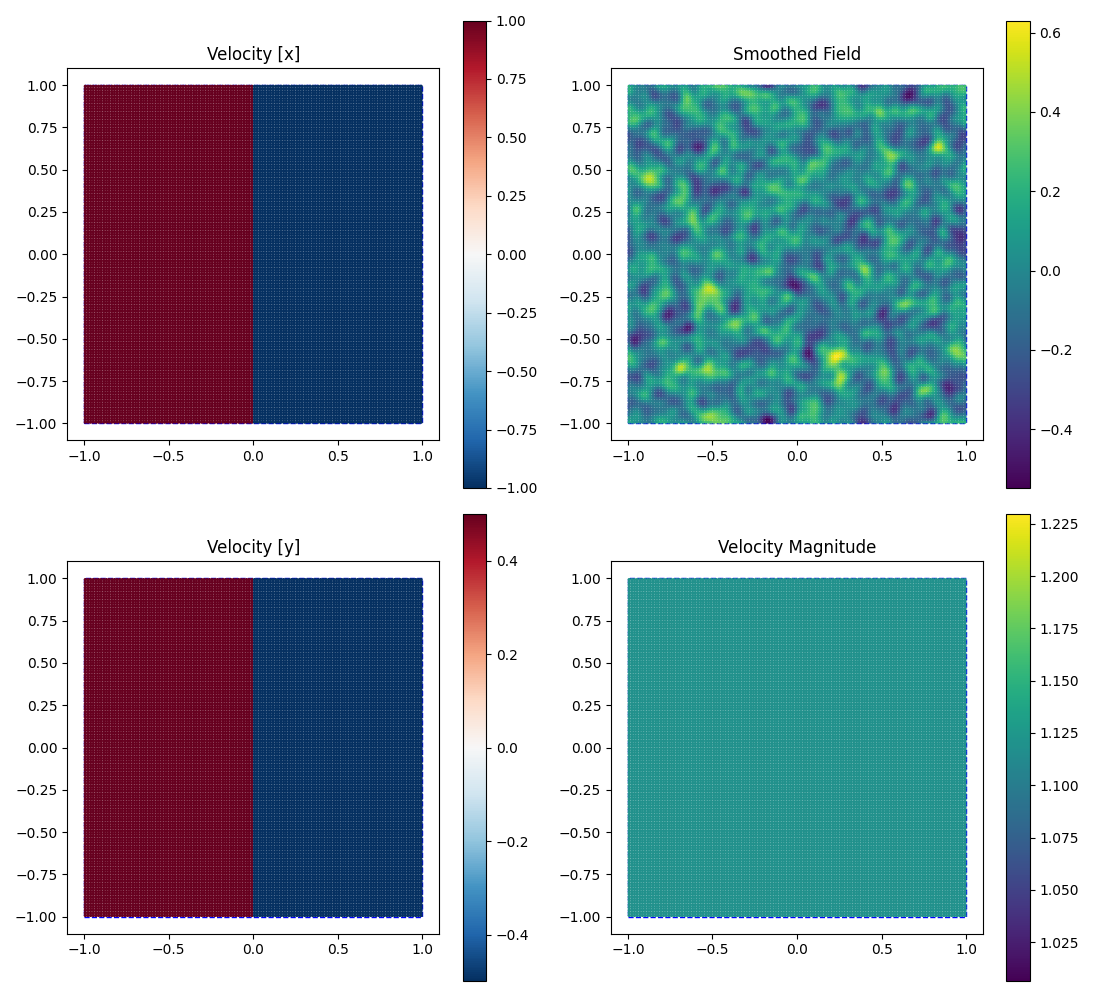

In [ ]:
f = torch.randn(numParticles, device=device, dtype=torch.float32)

f_smoothed = f.clone()

for _ in range(3):
    f_smoothed = sphOperation_warp(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_smoothed, f_smoothed,
        domain = domain, adjacency = adjacency, 
        operation = WarpOperation.Interpolate, operationMode = OperationDirection.AllToAll,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.SuperSymmetric,
    )


noiseGradient = sphOperation_warp(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_smoothed, f_smoothed,
        domain = domain, adjacency = adjacency,
        operation=WarpOperation.Gradient,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.SuperSymmetric,
        gradientMode = GradientScheme.Difference
)

velocities = torch.stack([noiseGradient[:,1], -noiseGradient[:,0]], dim = -1)
# velocities[queryPositions[:,0] < 0,:] = torch.tensor([1.0,0.5], device = velocities.device)
# velocities[queryPositions[:,0] > 0,:] = torch.tensor([-1.0,-0.5], device = velocities.device)

fig, axis = plt.subplots(2, 2, figsize = (11, 10), squeeze=False)


plotToAxis(fig, axis[0,0], velocities[:,0], "Velocity [x]", 'RdBu_r')
plotToAxis(fig, axis[1,0], velocities[:,1], "Velocity [y]", 'RdBu_r')

plotToAxis(fig, axis[0,1], f_smoothed, "Smoothed Field", 'viridis')
plotToAxis(fig, axis[1,1], torch.linalg.norm(velocities, dim=-1), "Velocity Magnitude", 'viridis')

fig.tight_layout()


In [10]:
divergence_warp = sphOperation_warp(
    queryPositions, referencePositions,
    querySupports, referenceSupports,
    queryMasses, referenceMasses,
    queryDensities, referenceDensities,
    velocities, velocities,
    domain = domain, adjacency = adjacency, 
    operation = WarpOperation.Divergence, operationMode = OperationDirection.AllToAll,
    kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.SuperSymmetric,
    gradientMode = GradientScheme.Difference
)

if not warpOnly:
    divergence_diffSPH = SPHOperation(
        simulationState,
        quantity = velocities,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Divergence,
        gradientMode=GradientMode.Difference,
        supportScheme = SupportScheme.SuperSymmetric,
        correctionTerms= [],
        positiveDivergence=False
    )



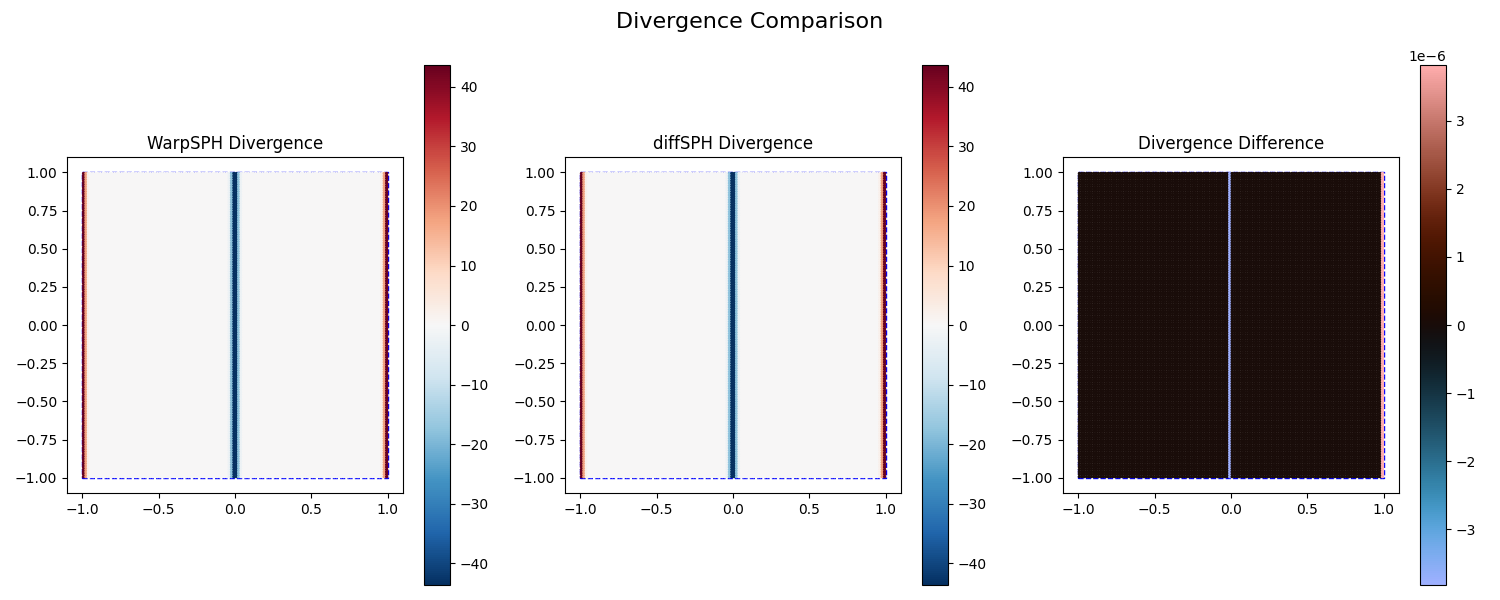

In [11]:
fig, axis = plt.subplots(1,3 if not warpOnly else 1, figsize = (15 if not warpOnly else 11,6), squeeze=False)
markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128


plotToAxis(fig, axis[0,0], divergence_warp, "WarpSPH Divergence", 'RdBu_r')

if not warpOnly:
    plotToAxis(fig, axis[0,1], divergence_diffSPH, "diffSPH Divergence", 'RdBu_r')

    diff_x = divergence_warp - divergence_diffSPH

    plotToAxis(fig, axis[0,2], diff_x, "Divergence Difference", 'berlin')

fig.suptitle("Divergence Comparison" if not warpOnly else "WarpSPH Divergence", fontsize = 16)
fig.tight_layout()
